# Easy Visa
Project Overview
In this project, you will apply your data science and machine learning skills to develop a predictive model for Easy Visa Dataset. This project will involve data cleaning, exploratory data analysis (EDA), data preprocessing, model training,hyperparameter tuning and evaluation.

## Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Phase 1: Data Collection and Preparation

In [8]:
# Load data from source

url = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv"

df = pd.read_csv(url)

row, col = df.shape

print(f"Data shape: rows {row} and columns {col}")

df.head(4)


Data shape: rows 25480 and columns 12


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# Let check for duplicate
df.duplicated().sum()

np.int64(0)

### Check for unique data in columns

In [25]:
df['case_id'].unique()

array(['EZYV01', 'EZYV02', 'EZYV03', ..., 'EZYV25478', 'EZYV25479',
       'EZYV25480'], shape=(25480,), dtype=object)

In [ ]:
df['continent'].unique()

array(['High School', "Master's", "Bachelor's", 'Doctorate'], dtype=object)

In [15]:
df["education_of_employee"].unique()

array(['High School', "Master's", "Bachelor's", 'Doctorate'], dtype=object)

In [16]:
df["has_job_experience"].unique()

array(['N', 'Y'], dtype=object)

In [17]:
df["requires_job_training"].unique()

array(['N', 'Y'], dtype=object)

In [18]:
df["no_of_employees"].unique()

array([14513,  2412, 44444, ..., 24335, 48785, 40224], shape=(7105,))

In [19]:
df["yr_of_estab"].unique()

array([2007, 2002, 2008, 1897, 2005, 2012, 1994, 1924, 1995, 2004, 1963,
       2006, 1987, 1991, 2001, 1972, 2013, 1968, 1884, 1981, 1997, 2009,
       1998, 1880, 2000, 2010, 1965, 1909, 2011, 1989, 1933, 1960, 2003,
       1976, 1996, 1847, 1935, 1890, 1999, 1838, 1947, 1939, 1970, 1977,
       1982, 1943, 1956, 1864, 1974, 1985, 1984, 1971, 1913, 1969, 1818,
       1839, 1914, 1988, 1944, 1855, 1975, 1966, 1801, 1920, 1925, 1993,
       1992, 1979, 1986, 1931, 1962, 1954, 1868, 1859, 1946, 1950, 1869,
       1917, 2014, 1980, 1896, 1949, 1843, 1850, 1906, 1961, 1951, 1958,
       1912, 1983, 1948, 1945, 1978, 1898, 1923, 1911, 1851, 1865, 1849,
       1872, 1967, 1926, 1873, 1848, 2015, 1889, 1876, 1852, 1938, 1973,
       1959, 1927, 1990, 1930, 1922, 1940, 1878, 1934, 1834, 1928, 1800,
       1861, 1952, 1846, 1885, 1907, 1817, 1841, 1821, 1953, 1888, 1916,
       1886, 2016, 1932, 1915, 1937, 1866, 1919, 1921, 1910, 1854, 1875,
       1904, 1879, 1942, 1964, 1899, 1900, 1837, 18

In [20]:
df["region_of_employment"].unique()

array(['West', 'Northeast', 'South', 'Midwest', 'Island'], dtype=object)

In [21]:
df["prevailing_wage"].unique()

array([   592.2029,  83425.65  , 122996.86  , ..., 146298.85  ,
        86154.77  ,  70876.91  ], shape=(25454,))

In [22]:
df['unit_of_wage'].unique()

array(['Hour', 'Year', 'Week', 'Month'], dtype=object)

In [23]:
df['full_time_position'].unique()

array(['Y', 'N'], dtype=object)

In [24]:
df['case_status'].unique()

array(['Denied', 'Certified'], dtype=object)

### Standardize wage for all employee to hrs

In [45]:
# ['Hour', 'Year', 'Week', 'Month']

def wage_per_hr(amount, duration):
    if duration == 'Year':
        return amount / 8766
    elif duration == "Month":
        return amount / 730.5
    elif duration == "Week":
        return amount / 168
    else:
        return amount


df["wage_per_hr"] = wage_per_hr(df['prevailing_wage'], df['unit_of_wage'].any())

df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,wage_per_hr
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,77092.57
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,279174.79
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,146298.85
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,86154.77
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified,70876.91


## Phase 2: Exploratory Data Analysis (EDA)

In [46]:
eda = df.copy()
eda.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,wage_per_hr
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,592.2029
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.6500
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.8600
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.0300
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.3900


### Univariate Analysis

In [47]:
def univariate_numerical_eda(df, column):
    """
    Performs univariate EDA on a single numerical column.
    Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """
    print(f" Feature: {column}")
    print("="*40)
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")

 Feature: no_of_employees
       no_of_employees
count     25480.000000
mean       5667.043210
std       22877.928848
min         -26.000000
25%        1022.000000
50%        2109.000000
75%        3504.000000
max      602069.000000

Skewness: 12.265
Kurtosis: 206.335


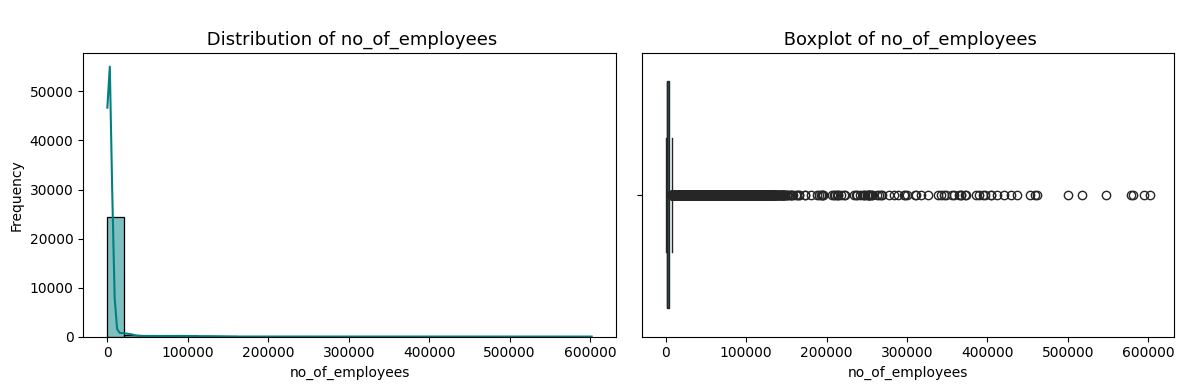


 no_of_employees is highly skewed. Consider log or Box-Cox transformation.


In [35]:
univariate_numerical_eda(eda, 'no_of_employees')


 Feature: yr_of_estab
        yr_of_estab
count  25480.000000
mean    1979.409929
std       42.366929
min     1800.000000
25%     1976.000000
50%     1997.000000
75%     2005.000000
max     2016.000000

Skewness: -2.037
Kurtosis: 3.507


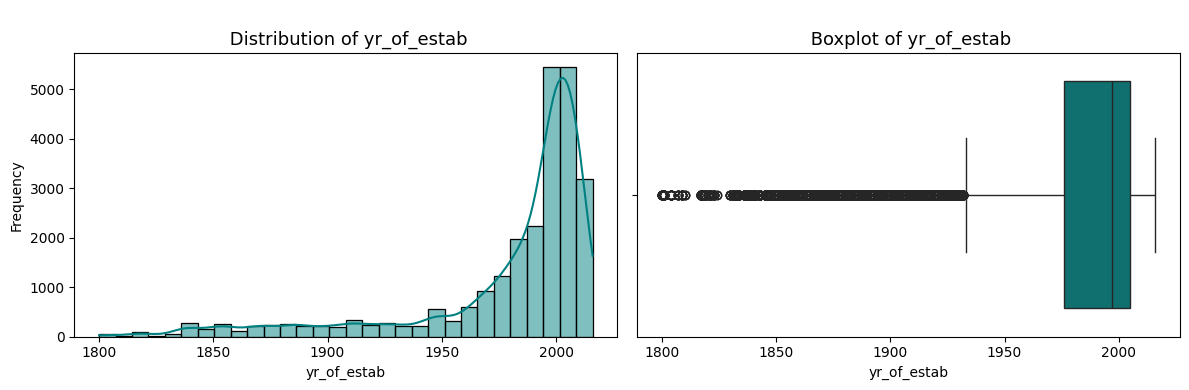


 yr_of_estab is highly skewed. Consider log or Box-Cox transformation.


In [48]:
univariate_numerical_eda(eda, 'yr_of_estab')
# eda.tail()

 Feature: wage_per_hr
         wage_per_hr
count   25480.000000
mean    74455.814592
std     52815.942327
min         2.136700
25%     34015.480000
50%     70308.210000
75%    107735.512500
max    319210.270000

Skewness: 0.756
Kurtosis: 0.824


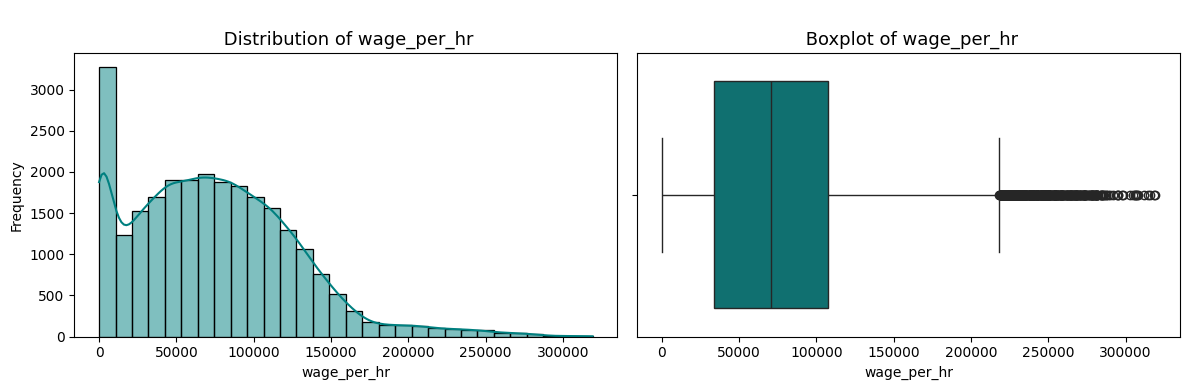

wage_per_hr is moderately skewed.


In [50]:
univariate_numerical_eda(eda, 'wage_per_hr')

In [54]:
def univariate_categorical_eda(df, column):
    """
    Performs univariate EDA on a categorical or ordinal column.
    Displays frequency table, proportion, and a countplot.
    """
    print(f"Feature: {column}")
    print("="*40)

    # Frequency + proportion
    freq = df[column].value_counts()
    prop = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    # Visualization
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with percentage
    total = len(eda[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()

Feature: continent
               Count  Percentage
continent                       
Asia           16861       66.17
Europe          3732       14.65
North America   3292       12.92
South America    852        3.34
Africa           551        2.16
Oceania          192        0.75



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


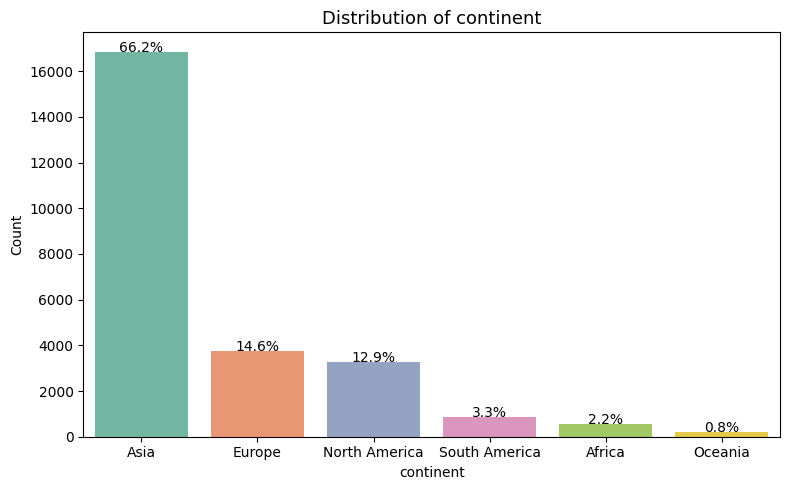

In [56]:
univariate_categorical_eda(eda,"continent" )
# eda.tail()

Feature: education_of_employee
                       Count  Percentage
education_of_employee                   
Bachelor's             10234       40.16
Master's                9634       37.81
High School             3420       13.42
Doctorate               2192        8.60



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


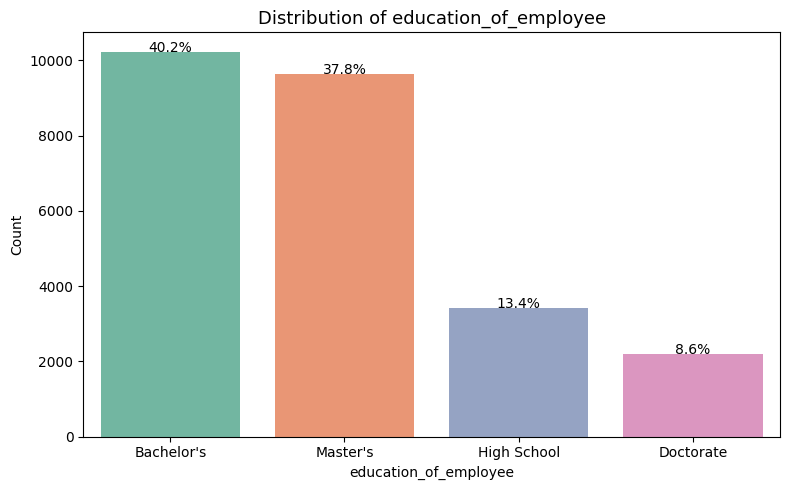

In [58]:
univariate_categorical_eda(eda,"education_of_employee" )
# eda.tail()

Feature: has_job_experience
                    Count  Percentage
has_job_experience                   
Y                   14802       58.09
N                   10678       41.91



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


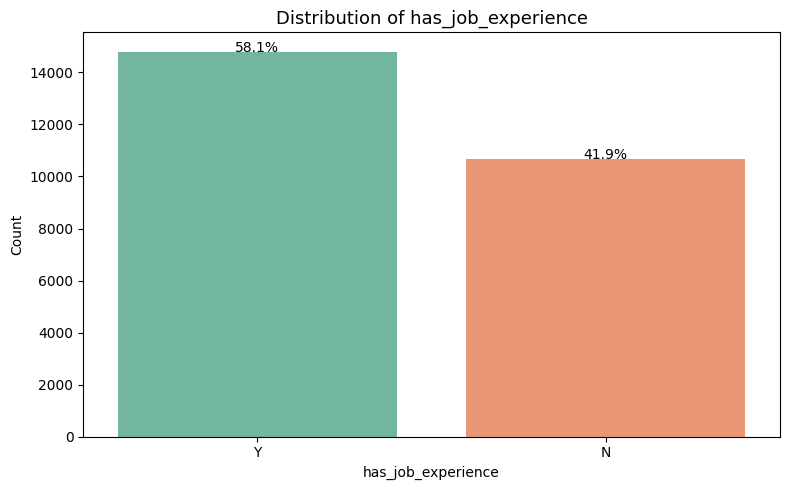

In [61]:
univariate_categorical_eda(eda,"has_job_experience" )

Feature: requires_job_training
                       Count  Percentage
requires_job_training                   
N                      22525        88.4
Y                       2955        11.6



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


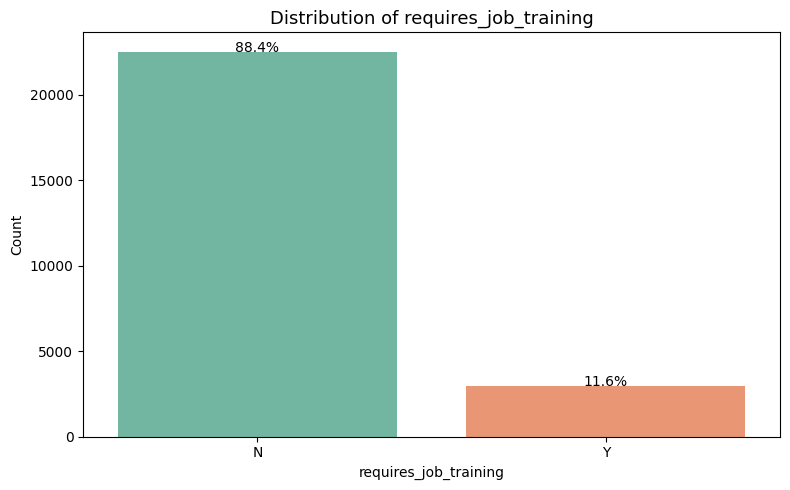

In [62]:
univariate_categorical_eda(eda,"requires_job_training" )

Feature: region_of_employment
                      Count  Percentage
region_of_employment                   
Northeast              7195       28.24
South                  7017       27.54
West                   6586       25.85
Midwest                4307       16.90
Island                  375        1.47



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


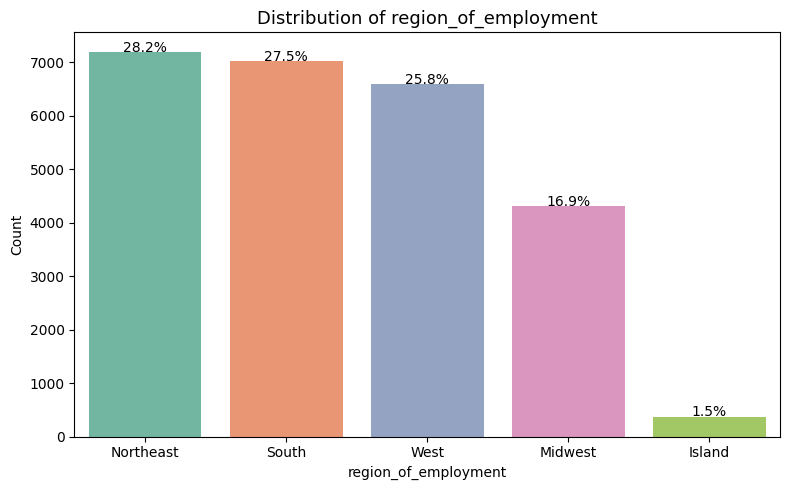

In [63]:
univariate_categorical_eda(eda,"region_of_employment" )

Feature: full_time_position
                    Count  Percentage
full_time_position                   
Y                   22773       89.38
N                    2707       10.62



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


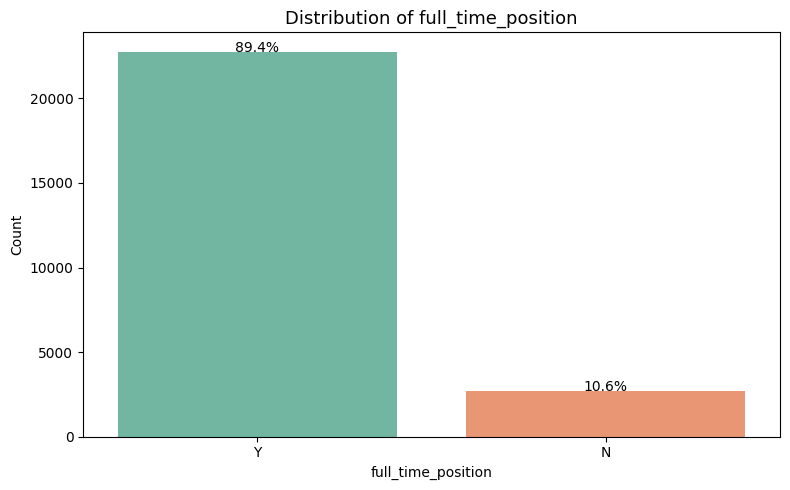

In [64]:
univariate_categorical_eda(eda,"full_time_position" )

Feature: case_status
             Count  Percentage
case_status                   
Certified    17018       66.79
Denied        8462       33.21



/var/folders/zt/8_dmsfz96kj95p979jph7bg40000gn/T/ipykernel_2415/3089895534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


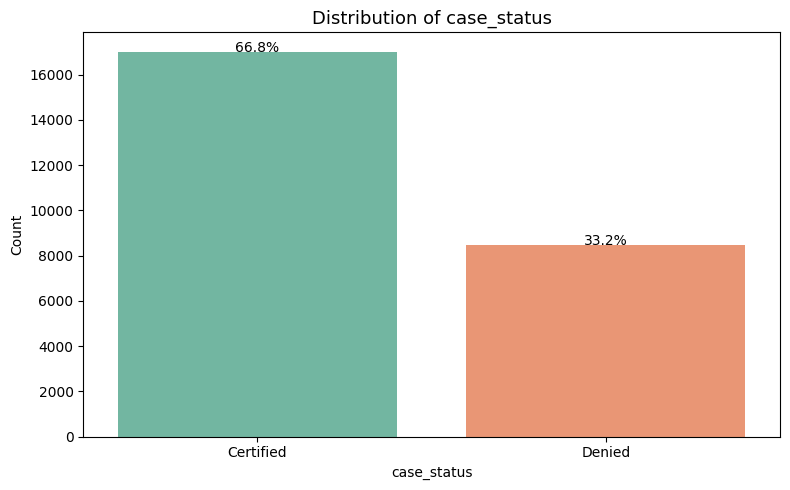

In [65]:
univariate_categorical_eda(eda,"case_status" )

### Bivariate Analysis

In [ ]:
# Lets find the numerical features
num_features = eda.select_dtypes(include=['int64', 'float64']).columns

def convert_case_status_num(item):
	if item == "Denied":
		return 1
	else:
		return 2
# convert to dataframe	
num_features = pd.DataFrame(eda[num_features])

num_features.head(2)
# eda.tail()
# eda['case_status'].head()


,no_of_employees,yr_of_estab,prevailing_wage,wage_per_hr,case_status_label
0,14513,2007,592.2029,592.2029,1
1,2412,2002,83425.6500,83425.6500,2


In [71]:
def correlation_with_target(df, target_col, figsize=(10,2)):
    """
    Plots a heatmap showing correlation of each numeric feature against target_col.
    Returns a Series of correlations (sorted by absolute magnitude).
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include='number').copy()
    if target_col not in numeric_df.columns:
        raise ValueError(f"Target column '{target_col}' must be numeric and present in the dataframe.")

    # compute correlations of every numeric column with the target
    corrs = numeric_df.corrwith(numeric_df[target_col]).drop(target_col)

    corrs_df = corrs.to_frame(name='corr').T  # shape (1, n)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'orientation': 'vertical', 'shrink':0.7}
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks([0], [target_col], rotation=0)
    plt.title(f'Correlation of numeric features with {target_col}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # return sorted correlations for downstream use
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index)


In [95]:
# correlation_with_target(num_features, 'case_status_label')
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,wage_per_hr
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,77092.57
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,279174.79
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,146298.85
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,86154.77
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified,70876.91
